# Hidden String 0110

# Project 5: Bernstein-Vazirani Algorithm

**Objective:** Discover a hidden $n$-bit binary string locked inside an Oracle in exactly one query. In this experiment, the hidden string is `0110`.

**Theory:**
Classically, finding a hidden $n$-bit string requires $n$ queries (testing `1000`, `0100`, `0010`, `0001` to reveal each bit). 

The **Bernstein-Vazirani** algorithm uses the "Hadamard Sandwich" to evaluate the oracle globally. By initializing the output qubit in the $|-\rangle$ state, the oracle's `CNOT` gates trigger **Phase Kickback**. This flips the phase of the input qubits corresponding to the `1`s in the secret string. When the final Hadamard gates are applied, the quantum state perfectly interferes to collapse into the classical hidden string with 100% certainty in just one query.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Environment Ready.")

Environment Ready.


## Step 1: Building the Secret Oracle

To encode a secret string using Phase Kickback, we apply a `CNOT` gate for every `1` in the string.
- **Control:** The input qubit corresponding to that index.
- **Target:** The ancilla (output) qubit.

*Note: Qiskit orders classical bits from right to left (Least Significant Bit on the far right). To make the final measurement match our string exactly, we must reverse the string when assigning the CNOT gates.*

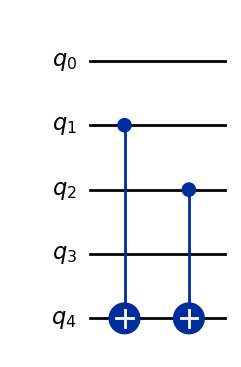

In [2]:
def build_bv_oracle(secret_string: str) -> QuantumCircuit:
    """Builds the Oracle containing the hidden string."""
    n = len(secret_string)
    
    # We need 'n' input qubits and 1 ancilla output qubit
    oracle = QuantumCircuit(n + 1, name="BV_Oracle")
    
    # Reverse the string to match Qiskit's right-to-left qubit ordering
    reversed_string = secret_string[::-1]
    
    # Apply a CNOT for every '1' in the string
    for i in range(n):
        if reversed_string[i] == '1':
            oracle.cx(i, n) # Control: i, Target: ancilla (n)
            
    return oracle

# Define our secret string and visualize the oracle
secret = "0110"
n_qubits = len(secret)
bv_oracle = build_bv_oracle(secret)

display(bv_oracle.draw('mpl'))

## Step 2: The Full Algorithm

We wrap the Oracle in our Hadamard sandwich:
1. Initialize the input qubits to $|0\rangle$ and the ancilla qubit to $|1\rangle$.
2. Apply $H$ gates to all qubits (ancilla becomes $|-\rangle$).
3. Apply the Oracle (Phase Kickback occurs).
4. Apply $H$ gates to the input qubits to interfere the phases.
5. Measure the input qubits.

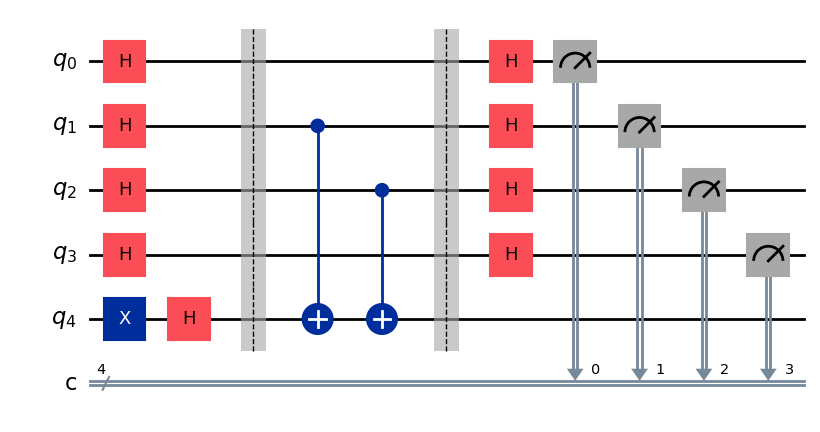

In [3]:
def bernstein_vazirani_circuit(secret_string: str) -> QuantumCircuit:
    """Constructs the full Bernstein-Vazirani circuit."""
    n = len(secret_string)
    qc = QuantumCircuit(n + 1, n)
    
    # 1. Prepare the ancilla (output) qubit in the |1> state
    qc.x(n)
    
    # 2. Apply H-gates to all qubits
    qc.h(range(n + 1))
    qc.barrier()
    
    # 3. Append the Oracle
    oracle = build_bv_oracle(secret_string)
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 4. Apply H-gates to the input register
    qc.h(range(n))
    
    # 5. Measure the input register
    qc.measure(range(n), range(n))
    
    return qc

# Build and visualize the complete circuit
bv_circuit = bernstein_vazirani_circuit(secret)
display(bv_circuit.draw('mpl'))

## Step 3: Execution and Verification

Execute the constructed circuit using the V2 `StatevectorSampler`.

**Verification:** The simulation should return the exact secret string (`0110`) with 100% probability in a single shot.

Algorithm Output: {'0110': 1024}


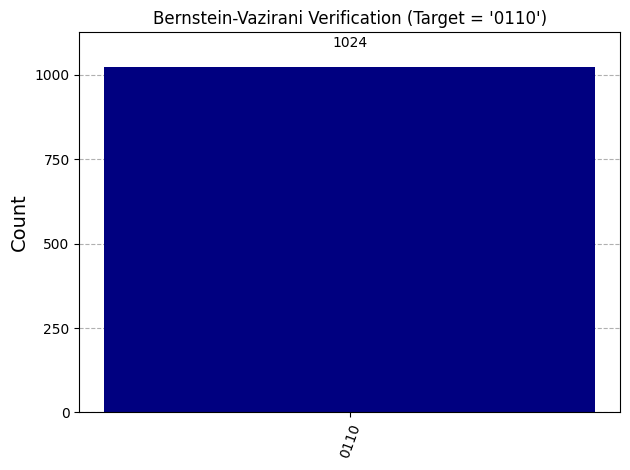

In [4]:
# Initialize the modern V2 Sampler
sampler = StatevectorSampler()

# Execute the circuit over 1024 shots
job = sampler.run([bv_circuit], shots=1024)
pub_result = job.result()[0]

# Extract counts from the classical register 'c'
counts = pub_result.data.c.get_counts()

print(f"Algorithm Output: {counts}")

# Plot the results to verify the 100% probability spike
display(plot_histogram(counts, title=f"Bernstein-Vazirani Verification (Target = '{secret}')", color='navy'))